# Paso 6 — Búsqueda híbrida

El paso 4 dejó un resultado que pedía continuación: **cada método gana en
consultas distintas.**

- Los embeddings arrasan donde BM25 sacaba cero (`Business Development`: 0,0 → 0,5).
- BM25 sigue siendo mejor donde la consulta usa literalmente las palabras de la
  oferta (`Leadership`: 0,7 frente a 0,3).

Cuando dos métodos fallan en sitios distintos, combinarlos debería superar a
ambos. Este cuaderno lo comprueba — y el resultado no es el que parecía.

## El giro

La primera medición dice que el híbrido gana con claridad. **Está mal**, y el
error es mío: elegí el parámetro de mezcla mirando el mismo conjunto con el que
después lo evalué.

Al corregirlo, la conclusión cambia lo suficiente como para que el cuaderno trate
esa corrección como su contenido principal.


In [1]:
# El orden importa: torch ANTES que pandas (WinError 1114 en Windows si se invierte).
from sentence_transformers import SentenceTransformer  # noqa: E402

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rank_bm25 import BM25Okapi

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESADO = RAIZ / "datos" / "procesado"
RESULTADOS = RAIZ / "resultados"
RESULTADOS.mkdir(exist_ok=True)

ACENTO = "#5E6AD2"
AVISO = "#e0803c"
GRIS = "#8A8F98"

pd.set_option("display.width", 195)

corpus = pd.read_parquet(PROCESADO / "corpus_preparado.parquet")
consultas = pd.read_parquet(PROCESADO / "consultas.parquet")
relevantes = {r.equipo: set(r.ids_relevantes) for r in consultas.itertuples()}
ids_corpus = corpus["id"].to_numpy()

# Los embeddings por trozo ya los calculó el cuaderno anterior.
vectores = np.load(PROCESADO / "vectores_trozos.npy")
de_oferta = np.load(PROCESADO / "trozo_de_oferta.npy")
modelo = SentenceTransformer("all-MiniLM-L6-v2")

print(f"corpus:    {len(corpus):,} ofertas")
print(f"vectores:  {vectores.shape[0]:,} trozos de {vectores.shape[1]} dimensiones")

C:\Users\Jhon Garcia\Documents\Repositorios\Repositorio - V2\Buscador semántico de ofertas de empleo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


corpus:    10,145 ofertas
vectores:  32,629 trozos de 384 dimensiones


In [2]:
def tokenizar(texto):
    return re.findall(r"[a-z][a-z0-9+#.]{1,}", texto.lower())


bm25 = BM25Okapi([tokenizar(t) for t in corpus["texto_limpio"]])


def normalizar(puntuaciones):
    """Lleva las puntuaciones al rango 0-1.

    Es imprescindible: BM25 devuelve valores sin cota superior y la similitud
    coseno va de -1 a 1. Sumarlos tal cual dejaría que BM25 dominara la mezcla
    por la escala, no por su calidad.
    """
    finitos = np.isfinite(puntuaciones)
    p = np.where(finitos, puntuaciones, puntuaciones[finitos].min())
    bajo, alto = p.min(), p.max()
    return (p - bajo) / (alto - bajo) if alto > bajo else np.zeros_like(p)


# Se calculan una sola vez las puntuaciones de cada método para cada consulta.
puntuaciones = {}
for fila in consultas.itertuples():
    bm = bm25.get_scores(tokenizar(fila.consulta))
    vector = modelo.encode([fila.consulta], normalize_embeddings=True)[0]
    emb = np.full(len(corpus), -np.inf)
    np.maximum.at(emb, de_oferta, vectores @ vector)
    puntuaciones[fila.equipo] = (normalizar(bm), normalizar(emb))

print(f"Puntuaciones calculadas para {len(puntuaciones)} consultas.")

Puntuaciones calculadas para 11 consultas.


In [3]:
def metricas(equipo, orden):
    rel = relevantes[equipo]
    ganancia = sum(1 / np.log2(p + 1) for p, i in enumerate(orden[:10], start=1) if i in rel)
    ideal = sum(1 / np.log2(p + 1) for p in range(1, min(10, len(rel)) + 1))
    return {
        "P@10": sum(1 for i in orden[:10] if i in rel) / 10,
        "MRR": next((1 / p for p, i in enumerate(orden, start=1) if i in rel), 0.0),
        "nDCG@10": ganancia / ideal if ideal else 0.0,
        "R@100": sum(1 for i in orden[:100] if i in rel) / len(rel),
    }


def evaluar(combinar):
    """`combinar` recibe las dos puntuaciones normalizadas y devuelve una."""
    filas = []
    for equipo, (bm, emb) in puntuaciones.items():
        orden = ids_corpus[np.argsort(-combinar(bm, emb))]
        filas.append({"equipo": equipo, **metricas(equipo, orden)})
    return pd.DataFrame(filas).set_index("equipo")


solo_bm25 = evaluar(lambda b, e: b)
solo_emb = evaluar(lambda b, e: e)

pd.DataFrame({"BM25": solo_bm25.mean(), "Embeddings": solo_emb.mean()}).round(4)

,BM25,Embeddings
P@10,0.1818,0.3182
MRR,0.3245,0.4820
nDCG@10,0.1812,0.3115
R@100,0.2134,0.2589


---

# 1. Método A — Reciprocal Rank Fusion

RRF es la forma más citada de combinar buscadores. Ignora las puntuaciones y usa
solo **la posición** de cada documento en cada lista:

$$\text{RRF}(d) = \sum_{m} \frac{1}{k + \text{posición}_m(d)}$$

Con `k = 60` por convención. Un documento que sale décimo en las dos listas
puntúa más que uno primero en una y ausente de la otra.

**Su gran virtud es no tener nada que ajustar.** No hay que decidir cuánto pesa
cada método, así que no hay forma de hacerse trampa — un detalle que va a resultar
importante dentro de un momento.

In [4]:
def posiciones(puntuacion):
    """Convierte puntuaciones en posiciones: 1 = el mejor."""
    orden = np.argsort(-puntuacion)
    resultado = np.empty(len(puntuacion))
    resultado[orden] = np.arange(1, len(puntuacion) + 1)
    return resultado


filas = []
for k in (10, 30, 60, 100):
    d = evaluar(lambda b, e, k=k: 1 / (k + posiciones(b)) + 1 / (k + posiciones(e)))
    filas.append({"k": k, **d.mean().round(4).to_dict()})

rrf = pd.DataFrame(filas).set_index("k")
rrf

,P@10,MRR,nDCG@10,R@100
k,,,,
10,0.2455,0.5116,0.2680,0.2796
30,0.3000,0.5275,0.3084,0.2889
60,0.3000,0.5298,0.3096,0.2970
100,0.2909,0.5334,0.3059,0.3083


### Qué se ve aquí

El mejor RRF (`k = 60`) da **P@10 = 0,300**. Los embeddings solos daban **0,318**.

**RRF empeora el resultado.** El método que más se recomienda para esto queda por
debajo de uno de sus dos ingredientes.

El motivo está en su diseño: RRF trata a los dos buscadores **como iguales**. Y
aquí no lo son — los embeddings casi duplican a BM25 (0,318 frente a 0,182).
Promediar posiciones a partes iguales arrastra al bueno hacia el malo.

RRF brilla cuando se combinan métodos de calidad parecida. No es el caso.

> Conviene guardar un detalle para más adelante: **este 0,300 es un número
> honesto**, porque `k = 60` es la convención y no se ha elegido mirando los
> resultados.

---

# 2. Método B — Fusión ponderada

Si los dos métodos no valen lo mismo, que no pesen lo mismo:

$$\text{puntuación}(d) = (1-\alpha)\cdot\text{BM25}(d) + \alpha\cdot\text{embedding}(d)$$

Con `α = 0` queda BM25 puro; con `α = 1`, embeddings puros. Lo interesante está
en medio.

Antes hay un paso obligatorio: **normalizar**. BM25 devuelve valores sin tope
superior y la similitud coseno va de −1 a 1. Sumarlos sin normalizar dejaría que
BM25 dominara por la escala de sus números, no por su calidad.

In [5]:
ALFAS = np.round(np.arange(0, 1.01, 0.05), 2)
METRICAS = ["P@10", "MRR", "nDCG@10", "R@100"]

# cubo[métrica] = tabla de consultas × alfas. Se calcula una vez y se reutiliza.
cubo = {m: pd.DataFrame(index=list(consultas["equipo"]), columns=ALFAS, dtype=float)
        for m in METRICAS}

for alfa in ALFAS:
    d = evaluar(lambda b, e, a=alfa: (1 - a) * b + a * e)
    for m in METRICAS:
        cubo[m][alfa] = d[m]

curva = pd.DataFrame({m: cubo[m].mean() for m in METRICAS})
curva.index.name = "alfa"
curva.round(4)

,P@10,MRR,nDCG@10,R@100
alfa,,,,
0.00,0.1818,0.3245,0.1812,0.2134
0.05,0.1909,0.3521,0.1928,0.2185
0.10,0.1909,0.3107,0.1861,0.2320
0.15,0.2000,0.3139,0.1933,0.2405
0.20,0.2182,0.3132,0.2071,0.2622
0.25,0.2273,0.3061,0.2132,0.2753
0.30,0.2364,0.3735,0.2299,0.2927
0.35,0.2727,0.3434,0.2481,0.3065
0.40,0.2818,0.3572,0.2598,0.3146


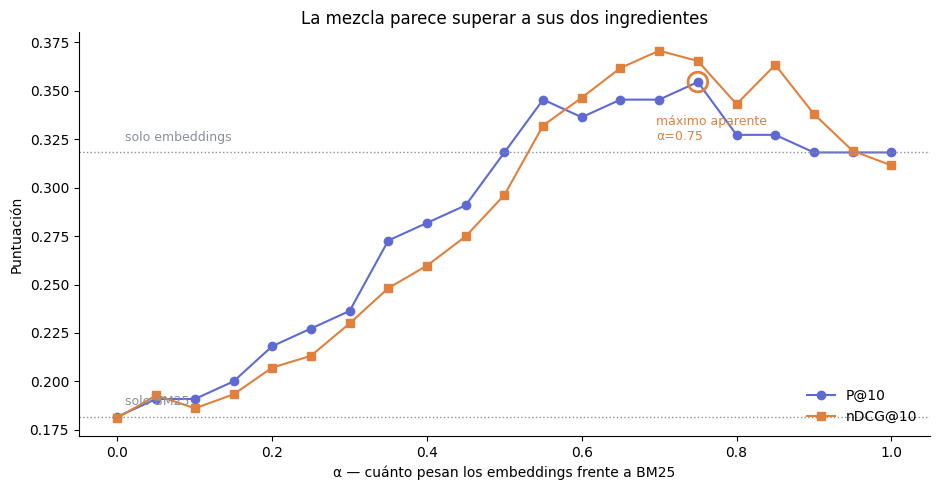

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5))

ax.plot(curva.index, curva["P@10"], marker="o", color=ACENTO, label="P@10")
ax.plot(curva.index, curva["nDCG@10"], marker="s", color=AVISO, label="nDCG@10")

mejor_alfa = curva["P@10"].idxmax()
ax.scatter([mejor_alfa], [curva["P@10"].max()], s=200, facecolors="none",
           edgecolors=AVISO, linewidths=2, zorder=5)
ax.annotate(f"máximo aparente\nα={mejor_alfa}", (mejor_alfa, curva["P@10"].max()),
            textcoords="offset points", xytext=(-30, -42), fontsize=9, color=AVISO)

ax.axhline(curva.loc[0.0, "P@10"], color=GRIS, linestyle=":", linewidth=1)
ax.text(0.01, curva.loc[0.0, "P@10"] + 0.006, "solo BM25", fontsize=9, color=GRIS)
ax.axhline(curva.loc[1.0, "P@10"], color=GRIS, linestyle=":", linewidth=1)
ax.text(0.01, curva.loc[1.0, "P@10"] + 0.006, "solo embeddings", fontsize=9, color=GRIS)

ax.set_xlabel("α — cuánto pesan los embeddings frente a BM25")
ax.set_ylabel("Puntuación")
ax.set_title("La mezcla parece superar a sus dos ingredientes")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "hibrido-curva-alfa.png", dpi=140)
plt.show()

### Qué se ve aquí

La curva tiene forma de montaña y su cima queda **por encima de los dos
extremos**:

| | P@10 |
|---|---|
| Solo BM25 (α = 0) | 0,182 |
| Solo embeddings (α = 1) | 0,318 |
| **Mezcla (α = 0,75)** | **0,355** |

Parece el final feliz: combinar mejora un 11 % sobre el mejor de los dos, y la
forma de la curva confirma que la ganancia es real y no un accidente de un punto
suelto.

**Pero este número está inflado, y el problema es de método, no de cálculo.**

---

# 3. La trampa: elegí α mirando la prueba

Repasemos qué acaba de pasar.

Probé 21 valores de α **sobre las once consultas de evaluación**, y me quedé con
el que mejor resultado daba **sobre esas mismas once consultas**.

Eso es exactamente el error que el paso 2 del proyecto anterior dedicó una
sección entera a evitar, solo que disfrazado: allí se trataba de elegir una
estrategia mirando la prueba; aquí, de elegir un hiperparámetro. **Es la misma
falta.**

Con once consultas, escoger el mejor de 21 valores garantiza pillar algo de
suerte. Parte de ese 0,355 no es que la mezcla funcione: es que α = 0,75 le venía
bien **a estas once consultas en particular**.

### Cómo se mide sin hacerse trampa

Lo correcto sería un conjunto de consultas aparte, reservado. Con once no da para
partirlo.

La alternativa es **dejar una fuera**: para cada consulta, se elige α usando **las
otras diez** y se evalúa sobre la excluida, que no participó en la elección. Once
veces, una por consulta.

Es lento de explicar y trivial de programar, y es la diferencia entre un número
que significa algo y uno que no.

In [7]:
filas = []
for metrica in METRICAS:
    M = cubo[metrica]
    alfa_aparente = M.mean().idxmax()

    # Dejando una fuera: α se elige con las otras diez consultas.
    honestos, alfas_usados = [], []
    for equipo in M.index:
        alfa = M.drop(index=equipo).mean().idxmax()
        honestos.append(M.loc[equipo, alfa])
        alfas_usados.append(alfa)

    filas.append({
        "métrica": metrica,
        "BM25": round(M[0.0].mean(), 4),
        "Embeddings": round(M[1.0].mean(), 4),
        "Híbrido aparente": round(M.mean().max(), 4),
        "α": alfa_aparente,
        "Híbrido honesto": round(np.mean(honestos), 4),
    })

honestidad = pd.DataFrame(filas).set_index("métrica")
honestidad["inflado por"] = (
    honestidad["Híbrido aparente"] - honestidad["Híbrido honesto"]
).round(4)
honestidad["gana a embeddings"] = (
    honestidad["Híbrido honesto"] - honestidad["Embeddings"]
).round(4)
honestidad

,BM25,Embeddings,Híbrido aparente,α,Híbrido honesto,inflado por,gana a embeddings
métrica,,,,,,,
P@10,0.1818,0.3182,0.3545,0.75,0.3182,0.0363,0.0000
MRR,0.3245,0.4820,0.6478,0.85,0.5569,0.0909,0.0749
nDCG@10,0.1812,0.3115,0.3707,0.70,0.3437,0.0270,0.0322
R@100,0.2134,0.2589,0.3247,0.75,0.3141,0.0106,0.0552


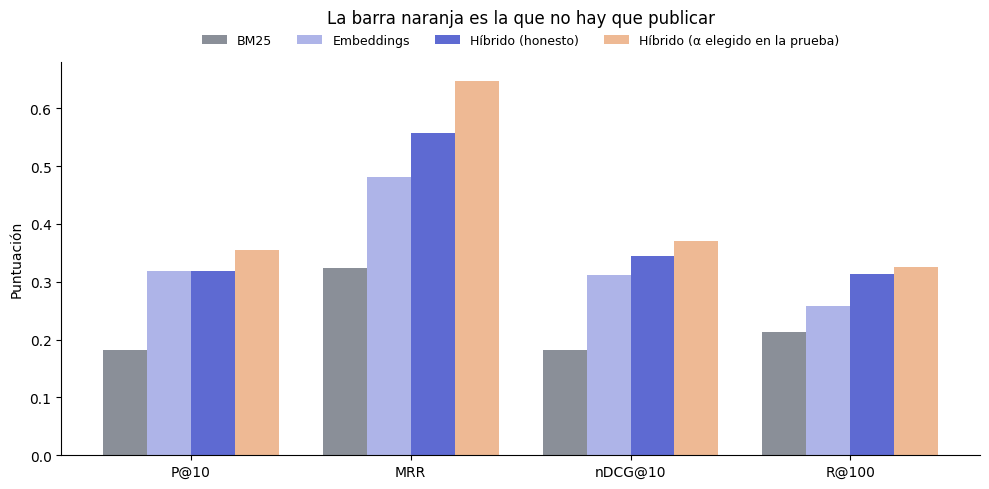

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
posicion = np.arange(len(METRICAS))
ancho = 0.2

ax.bar(posicion - 1.5 * ancho, honestidad["BM25"], ancho, label="BM25", color=GRIS)
ax.bar(posicion - 0.5 * ancho, honestidad["Embeddings"], ancho,
       label="Embeddings", color=ACENTO, alpha=0.5)
ax.bar(posicion + 0.5 * ancho, honestidad["Híbrido honesto"], ancho,
       label="Híbrido (honesto)", color=ACENTO)
ax.bar(posicion + 1.5 * ancho, honestidad["Híbrido aparente"], ancho,
       label="Híbrido (α elegido en la prueba)", color=AVISO, alpha=0.55)

ax.set_xticks(posicion, METRICAS)
ax.set_ylabel("Puntuación")
ax.set_title("La barra naranja es la que no hay que publicar", pad=28)
ax.legend(frameon=False, loc="lower center", bbox_to_anchor=(0.5, 1.01), ncol=4,
          fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTADOS / "hibrido-honesto.png", dpi=140)
plt.show()

### Qué se ve aquí — el resultado del cuaderno

| Métrica | BM25 | Embeddings | Híbrido aparente | **Híbrido honesto** | Gana a embeddings |
|---|---|---|---|---|---|
| **P@10** | 0,182 | 0,318 | 0,355 | **0,318** | **0,000** |
| MRR | 0,325 | 0,482 | 0,648 | **0,557** | **+0,075** |
| nDCG@10 | 0,181 | 0,312 | 0,371 | **0,344** | **+0,032** |
| R@100 | 0,213 | 0,259 | 0,325 | **0,314** | **+0,055** |

**En P@10 la mejora del híbrido era cero.** El 0,355 y el 0,318 de los
embeddings solos coinciden hasta el último decimal una vez que α se elige sin
mirar la respuesta. **Toda la ganancia aparente era sobreajuste al conjunto de
evaluación.**

Si el cuaderno se hubiera detenido en el apartado 2, habría publicado una mejora
del 11 % que no existe.

**Pero las otras tres métricas sí mejoran de verdad**, y eso merece leerse con
cuidado:

- **MRR +15,5 %** (0,482 → 0,557) — el primer acierto aparece más arriba.
- **R@100 +21,3 %** (0,259 → 0,314) — encuentra más ofertas relevantes.
- **nDCG@10 +10,3 %** (0,312 → 0,344) — las que hay están mejor ordenadas.

> **La conclusión con matiz:** el híbrido **no mete más aciertos en el top 10**
> —P@10 idéntico— pero **los coloca más arriba y encuentra más en el top 100**.
>
> Es una mejora real y útil, solo que no la que mide el P@10. Y solo se ve al
> mirar las cuatro métricas: con una sola, la conclusión habría sido «no sirve» o
> «mejora un 11 %», y las dos habrían sido falsas.

---

# 4. Dónde ayuda la mezcla

Con α elegido honestamente, se mira consulta por consulta.

In [9]:
M = cubo["P@10"]
alfa_honesto = {e: M.drop(index=e).mean().idxmax() for e in M.index}

comparacion = pd.DataFrame({
    "BM25": solo_bm25["P@10"],
    "Embeddings": solo_emb["P@10"],
    "Híbrido": pd.Series({e: M.loc[e, a] for e, a in alfa_honesto.items()}),
    "α usado": pd.Series(alfa_honesto),
    "relevantes": consultas.set_index("equipo")["relevantes"],
})
comparacion["vs mejor"] = (
    comparacion["Híbrido"] - comparacion[["BM25", "Embeddings"]].max(axis=1)
).round(2)

oraculo = comparacion[["BM25", "Embeddings"]].max(axis=1).mean()
print(f"Oráculo que eligiera el mejor método en cada consulta: P@10 = {oraculo:.4f}")
print(f"Híbrido con un α fijo:                                 P@10 = "
      f"{comparacion['Híbrido'].mean():.4f}\n")

comparacion.sort_values("vs mejor", ascending=False)

Oráculo que eligiera el mejor método en cada consulta: P@10 = 0.3727
Híbrido con un α fijo:                                 P@10 = 0.3182



,BM25,Embeddings,Híbrido,α usado,relevantes,vs mejor
People,0.0,0.0,0.1,0.75,94,0.1
Engineering,0.2,0.7,0.7,0.55,216,0.0
Business Development & Support,0.0,0.5,0.5,0.75,156,0.0
Product,0.3,0.2,0.3,0.75,47,0.0
Customer Service,0.0,0.0,0.0,0.75,38,0.0
Data Science & Analytics,0.1,0.2,0.2,0.75,39,0.0
Finance & Legal,0.2,0.2,0.2,0.55,40,0.0
Marketing & Communications,0.4,0.3,0.3,0.75,46,-0.1
Design & User Experience,0.1,0.8,0.6,0.55,48,-0.2
Security & Infrastructure,0.0,0.3,0.1,0.75,61,-0.2


### Qué se ve aquí — la mezcla reparte, no suma

La columna `vs mejor` compara el híbrido con **el mejor de los dos métodos en esa
consulta concreta**. El reparto es peor de lo que sugería el promedio:

| | Consultas |
|---|---|
| Mejora | **1** — `People` (+0,1) |
| Empata | **6** |
| Empeora | **4** — `Marketing` (−0,1), `Design & UX`, `Security & Infra`, `Leadership` (−0,2) |

**La mezcla no suma las virtudes de los dos métodos: negocia entre ellas.**

`Leadership` lo ilustra bien. BM25 sacaba 0,7 y los embeddings 0,3; el híbrido
queda en 0,5 — mejor que los embeddings, pero **peor que BM25**. La mezcla se
coloca entre los dos, que es justo lo que hace un promedio ponderado. Lo mismo al
revés en `Design & User Experience`: de 0,8 con embeddings a 0,6.

El único caso donde gana a los dos es `People`, y pasa de 0,0 a 0,1 — una sola
oferta acertada.

### El techo de esta idea

Si un oráculo eligiera, para cada consulta, **el mejor de los dos métodos**,
sacaría **0,373** de P@10. El híbrido con un α fijo se queda en 0,318.

Ahí está el problema de fondo: **el peso óptimo depende de la consulta, no del
sistema.** `Leadership` querría α bajo y `Security & Infrastructure` querría
α = 1. Un solo número para las once es un compromiso.

Elegir α por consulta exigiría saber de antemano cuál va a funcionar mejor — que
es el problema original otra vez. Esa sí sería una línea de trabajo interesante:
predecir, a partir de la consulta, cuánto conviene fiarse de cada método.

In [10]:
resumen = pd.DataFrame([
    {"método": "Aleatorio (control)", "P@10": 0.0071, "MRR": 0.0366,
     "nDCG@10": 0.0075, "R@100": 0.0102},
    {"método": "BM25", **solo_bm25.mean().round(4).to_dict()},
    {"método": "Embeddings (troceado)", **solo_emb.mean().round(4).to_dict()},
    {"método": "RRF (k=60, sin ajustar)",
     **rrf.loc[60, METRICAS].round(4).to_dict()},
    {"método": "Híbrido ponderado (honesto)",
     **honestidad["Híbrido honesto"].to_dict()},
]).set_index("método")

resumen.to_parquet(PROCESADO / "resultados_finales.parquet")
print(resumen.to_string())

                               P@10     MRR  nDCG@10   R@100
método                                                      
Aleatorio (control)          0.0071  0.0366   0.0075  0.0102
BM25                         0.1818  0.3245   0.1812  0.2134
Embeddings (troceado)        0.3182  0.4820   0.3115  0.2589
RRF (k=60, sin ajustar)      0.3000  0.5298   0.3096  0.2970
Híbrido ponderado (honesto)  0.3182  0.5569   0.3437  0.3141


---

# Resumen

## Resultado final del proyecto

| Método | P@10 | MRR | nDCG@10 | R@100 |
|---|---|---|---|---|
| Aleatorio (control) | 0,007 | 0,037 | 0,008 | 0,010 |
| BM25 | 0,182 | 0,325 | 0,181 | 0,213 |
| RRF (k=60, sin ajustar) | 0,300 | 0,530 | 0,310 | 0,297 |
| Embeddings (troceado) | 0,318 | 0,482 | 0,312 | 0,259 |
| **Híbrido ponderado (honesto)** | **0,318** | **0,557** | **0,344** | **0,314** |

Frente a BM25, el sistema final **multiplica el P@10 por 1,75 y el R@100 por
1,47**, y sobre el azar el P@10 se multiplica por 45.

## Los cuatro hallazgos

1. **RRF empeora el resultado** (0,300 frente a 0,318 de los embeddings solos).
   El método más recomendado para combinar buscadores trata a los dos como
   iguales, y aquí uno casi duplica al otro. RRF sirve cuando los ingredientes se
   parecen en calidad.

2. **La mejora del híbrido en P@10 era exactamente cero.** El 0,355 salía de
   elegir α mirando las mismas once consultas con las que luego se evaluaba.
   Medido dejando una consulta fuera, el híbrido iguala a los embeddings solos.

3. **Pero sí mejora las otras tres métricas**: MRR +15,5 %, R@100 +21,3 %,
   nDCG@10 +10,3 %. **No mete más aciertos en el top 10; los coloca más arriba y
   encuentra más en el top 100.** Con una sola métrica la conclusión habría sido
   falsa en cualquiera de las dos direcciones.

4. **La mezcla reparte, no suma.** Con α honesto, el híbrido mejora en **1**
   consulta, empata en 6 y **empeora en 4**: se coloca entre los dos métodos, que
   es lo que hace un promedio. Un oráculo que eligiera el mejor método en cada
   consulta sacaría **0,373**; el α fijo se queda en 0,318. **El peso óptimo
   depende de la consulta, no del sistema.**

## La lección de método

Es la misma que dejó el proyecto anterior, con otro disfraz: allí era **elegir la
estrategia** mirando la prueba, aquí **elegir un hiperparámetro**.

> Cualquier decisión tomada mirando el conjunto de evaluación —qué modelo, qué
> preprocesado, qué valor de un parámetro— **infla el resultado**. Con once
> consultas y 21 valores de α, la inflación fue del 11 %.

**Y una consecuencia práctica:** RRF no tiene nada que ajustar, así que su cifra
es honesta por construcción. Cuando no hay consultas de sobra para reservar, eso
vale más de lo que parece.

## Siguiente paso

Queda el paso 7: una demo donde se escriba una consulta y salgan resultados, la
búsqueda en español con un modelo multilingüe —etiquetada como capacidad extra,
no como parte del experimento— y cerrar el README.
